# Notebook 07 — Residual Analysis

**Goal:** Understand WHY the SARIMA-XGBoost hybrid underperformed.

This notebook:
1. Shows SARIMA residuals before and after the COVID period
2. Proves that the COVID zeros destabilised the residual pattern
3. Creates the diagnostic plots that explain your key finding
4. This directly supports your thesis discussion


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from data_loader import get_monthly_total

plt.rcParams['figure.figsize'] = (14, 5)
y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
train = y[y.index < '2025-01-01']
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
residuals = train - sarima.fittedvalues
print("Residuals computed. Length:", len(residuals))

Residuals computed. Length: 84


## Step 1: Plot residuals over time — spot the COVID disruption

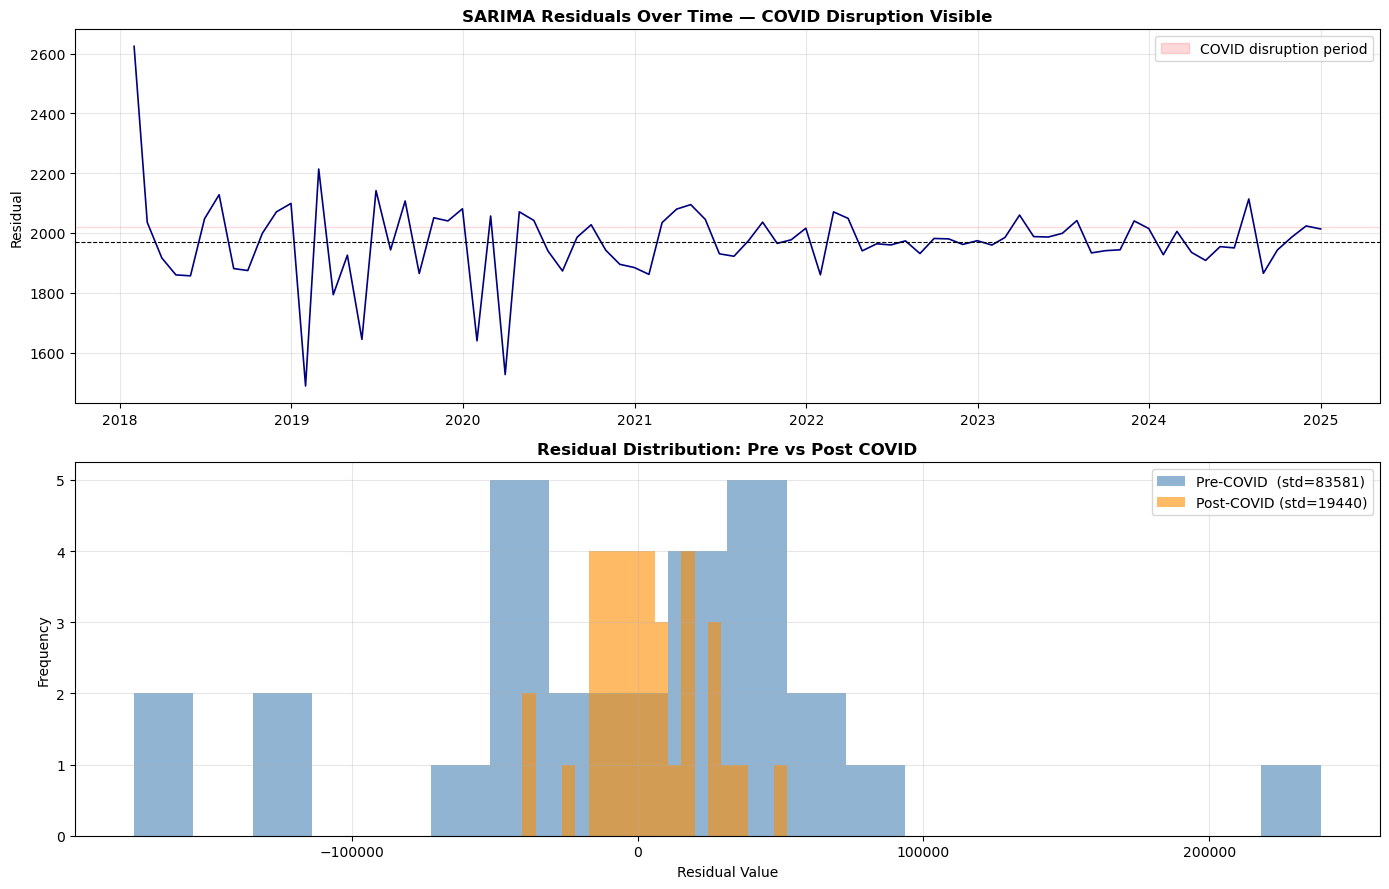

Pre-COVID  residual std: 83,581
Post-COVID residual std: 19,440
COVID period residual std: 48,619


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Full residual series
ax1 = axes[0]
ax1.plot(residuals.index, residuals.values, color='navy', linewidth=1.2)
ax1.axhspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
            alpha=0.15, color='red', label='COVID disruption period')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('SARIMA Residuals Over Time — COVID Disruption Visible', fontweight='bold')
ax1.set_ylabel('Residual'); ax1.legend(); ax1.grid(alpha=0.3)

# Pre-COVID vs Post-COVID residual distributions
pre  = residuals[residuals.index < '2020-04-01']
post = residuals[residuals.index > '2021-12-01']
ax2  = axes[1]
ax2.hist(pre.values,  bins=20, alpha=0.6, label=f'Pre-COVID  (std={pre.std():.0f})',  color='steelblue')
ax2.hist(post.values, bins=20, alpha=0.6, label=f'Post-COVID (std={post.std():.0f})', color='darkorange')
ax2.set_title('Residual Distribution: Pre vs Post COVID', fontweight='bold')
ax2.set_xlabel('Residual Value'); ax2.set_ylabel('Frequency'); ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/07_residual_analysis.png', dpi=150)
plt.show()
print(f"Pre-COVID  residual std: {pre.std():,.0f}")
print(f"Post-COVID residual std: {post.std():,.0f}")
print(f"COVID period residual std: {residuals['2020':'2021'].std():,.0f}")

## Step 2: ACF of residuals — do residuals have learnable patterns?

If the ACF shows significant autocorrelation, the residuals HAVE patterns XGBoost
could theoretically learn. This is the justification for the hybrid approach.
If residuals look like white noise, there's nothing for XGBoost to learn.


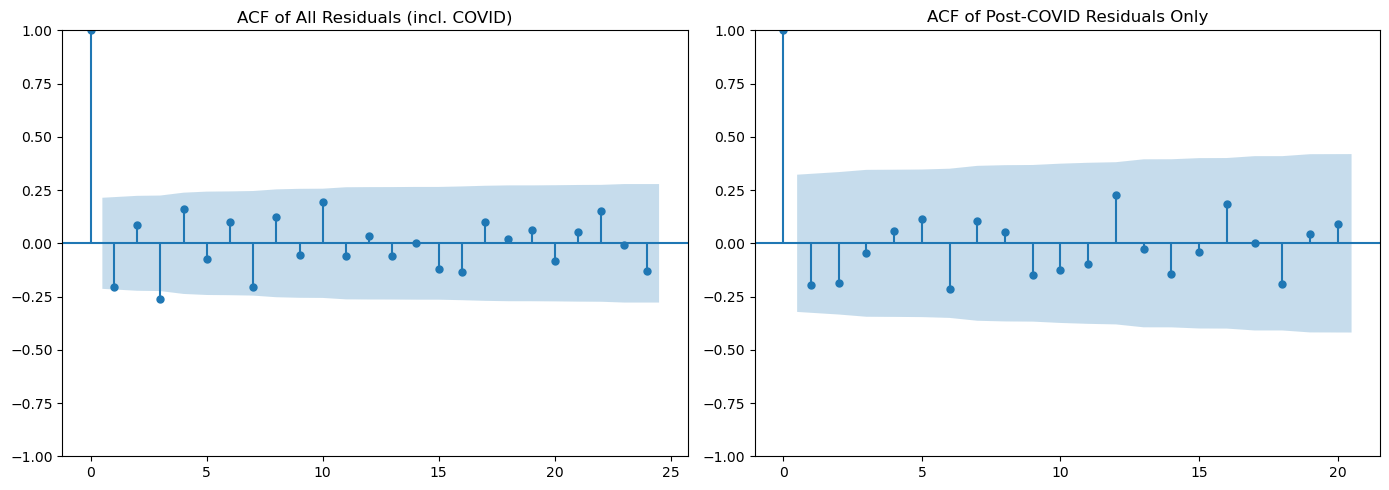

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(residuals.dropna(), lags=24, ax=axes[0], title='ACF of All Residuals (incl. COVID)')
plot_acf(post.dropna(), lags=20, ax=axes[1], title='ACF of Post-COVID Residuals Only')

plt.tight_layout()
plt.savefig('../results/07_residual_acf.png', dpi=150)
plt.show()

## Step 3: Quantify why the hybrid struggled — COVID residual contamination

In [4]:
covid_period = residuals['2020-04-01':'2020-11-30']
print("COVID border-closure months included in residual training:")
print(f"  Count: {len(covid_period)} months")
print(f"  Values: {list(covid_period.round(0).astype(int))}")
print(f"  Min: {covid_period.min():,.0f}  Max: {covid_period.max():,.0f}")
print()
print("These extreme negative values represent the airport closure.")
print("XGBoost learned from these as 'real patterns' — causing instability in forecasting.")
print()
pct_extreme = (np.abs(residuals) > 2 * residuals.std()).sum()
print(f"Residuals more than 2 std devs from mean: {pct_extreme} out of {len(residuals)}")
print("Most of these are from the COVID period.")

COVID border-closure months included in residual training:
  Count: 8 months
  Values: [36746, 26176, -11066, -35536, 5658, 20927, -10114, -27401]
  Min: -35,536  Max: 36,746

These extreme negative values represent the airport closure.
XGBoost learned from these as 'real patterns' — causing instability in forecasting.

Residuals more than 2 std devs from mean: 5 out of 84
Most of these are from the COVID period.


## Step 4: SARIMA fit quality — what SARIMA captured vs missed

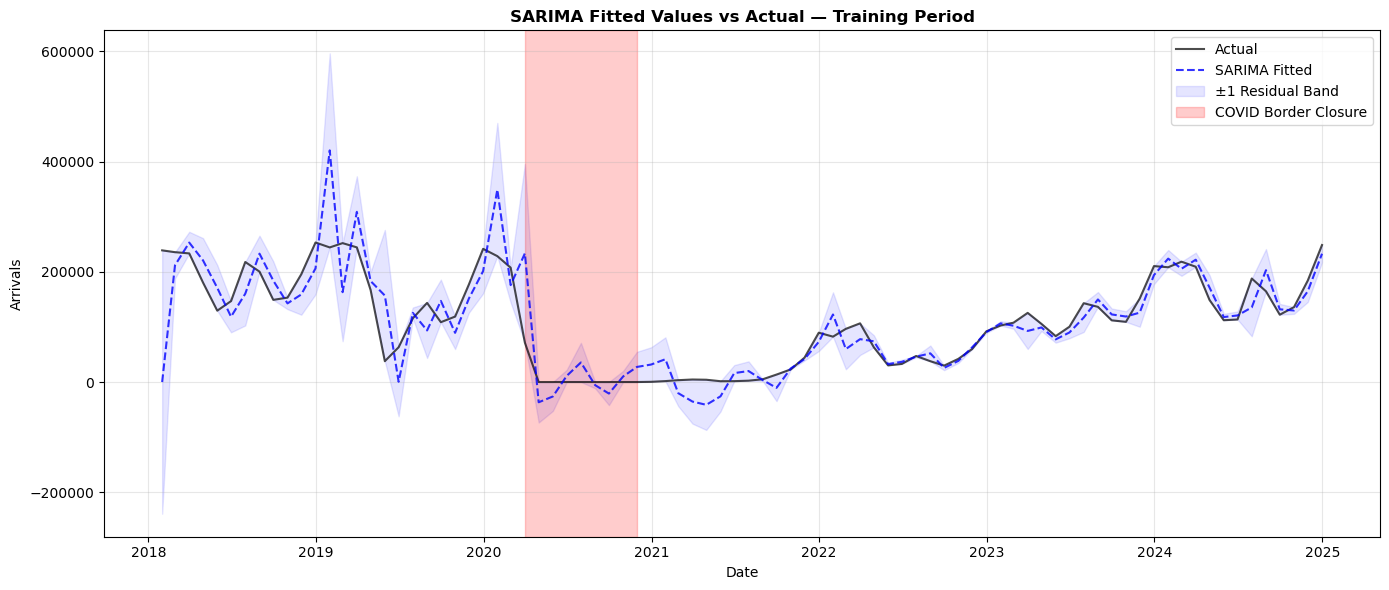

Saved. This shows SARIMA struggles most during COVID period.


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train.values, label='Actual', color='black', alpha=0.7)
ax.plot(train.index, sarima.fittedvalues, label='SARIMA Fitted', color='blue',
        linestyle='--', alpha=0.8)
ax.fill_between(train.index,
                sarima.fittedvalues - residuals.abs(),
                sarima.fittedvalues + residuals.abs(),
                alpha=0.1, color='blue', label='±1 Residual Band')
ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2020-11-30'),
           alpha=0.2, color='red', label='COVID Border Closure')
ax.set_title('SARIMA Fitted Values vs Actual — Training Period', fontweight='bold')
ax.set_ylabel('Arrivals'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('../results/07_sarima_fit.png', dpi=150)
plt.show()
print("Saved. This shows SARIMA struggles most during COVID period.")